E-commerce Client Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("customer_profile.csv")
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [15]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


Найдем клиентов, которые тратят больше, чем остальные 90%.

In [17]:
vip_threshold = df['Total Spend'].quantile(0.9)
print(f"Граница для VIP-клиентов: {vip_threshold:.2f}")

Граница для VIP-клиентов: 1460.50


In [19]:
df['VIP_Flag'] = df['Total Spend'].apply(lambda x: 'VIP' if x >= vip_threshold else 'Обычный')
df[['Total Spend', 'VIP_Flag']].head()

,Total Spend,VIP_Flag
0,1120.20,Обычный
1,780.50,Обычный
2,510.75,Обычный
3,1480.30,VIP
4,720.40,Обычный


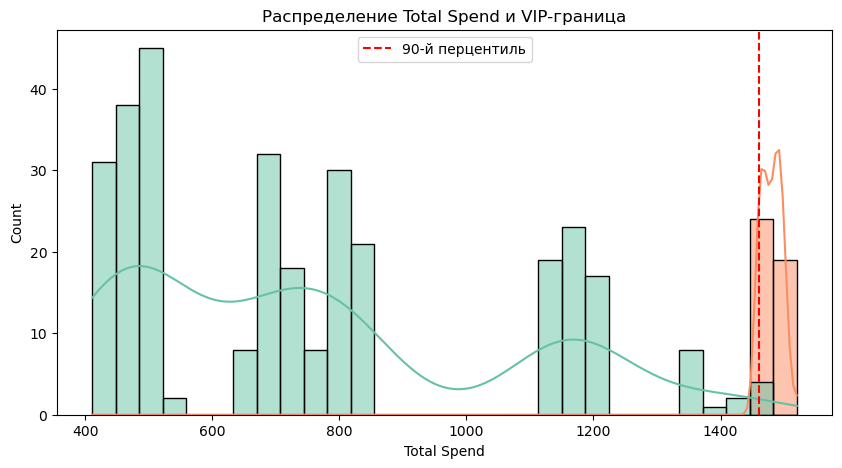

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Total Spend', bins=30, hue='VIP_Flag', kde=True, palette='Set2')
plt.axvline(vip_threshold, color='red', linestyle='--', label='90-й перцентиль')
plt.title('Распределение Total Spend и VIP-граница')
plt.legend()
plt.show()

Проанализируем различия между категориями клиентов

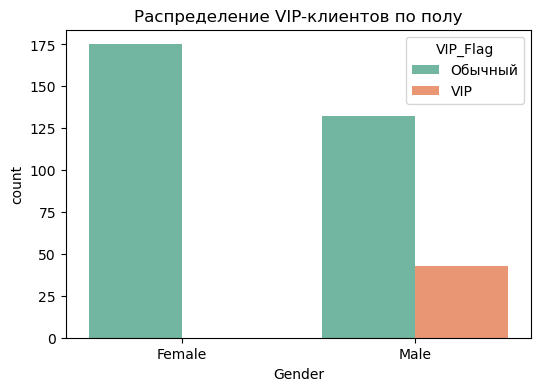

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', hue='VIP_Flag', palette='Set2')
plt.title("Распределение VIP-клиентов по полу")
plt.show()

In [35]:
df['Gender'].value_counts()

Gender
Female    175
Male      175
Name: count, dtype: int64

In [37]:
df.groupby('VIP_Flag')['Gender'].value_counts(normalize=True)

VIP_Flag  Gender
VIP       Male      1.000000
Обычный   Female    0.570033
          Male      0.429967
Name: proportion, dtype: float64

Все VIP-клиенты в текущей выборке — мужчины. Среди обычных клиентов преобладают женщины (57%).
Это может свидетельствовать о разнице в покупательском поведении между полами: мужчины, хотя и составляют меньшую часть клиентов, демонстрируют более высокий уровень трат.
Альтернативно, возможен дисбаланс в выборке данных, который стоит учитывать при интерпретации.

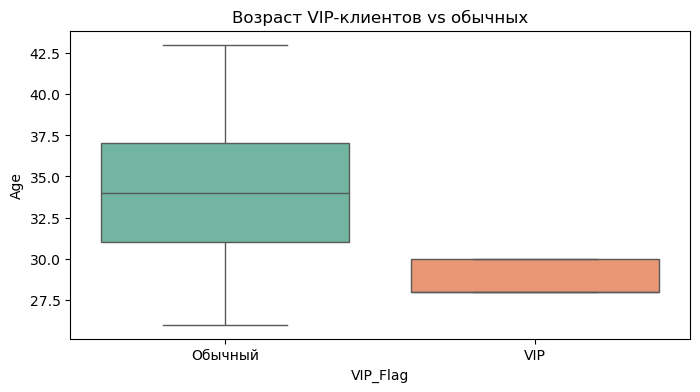

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='VIP_Flag', y='Age', hue='VIP_Flag', palette='Set2', legend=False)
plt.title("Возраст VIP-клиентов vs обычных")
plt.show()

In [27]:
median_by_vip = df.groupby('VIP_Flag')['Age'].median()
print(median_by_vip)

VIP_Flag
VIP        28.0
Обычный    34.0
Name: Age, dtype: float64


Средний возраст VIP-клиентов составляет 28 лет, что заметно ниже, чем у обычных пользователей (34 года). Это может указывать на высокую активность и покупательскую способность среди более молодой аудитории.

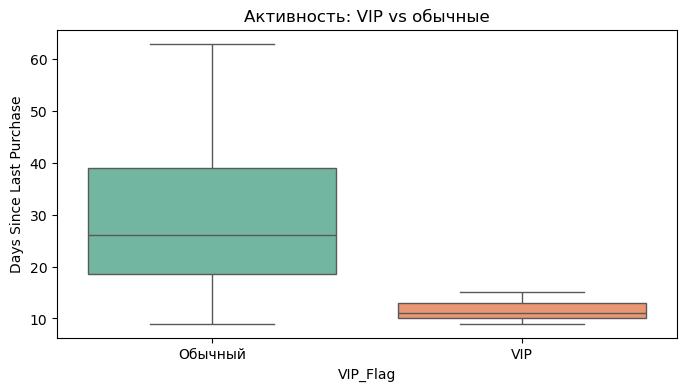

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='VIP_Flag', y='Days Since Last Purchase', hue='VIP_Flag', palette='Set2', legend=False)
plt.title("Активность: VIP vs обычные")
plt.show()

In [39]:
df.groupby('VIP_Flag')['Days Since Last Purchase'].median()

VIP_Flag
VIP        11.0
Обычный    26.0
Name: Days Since Last Purchase, dtype: float64

In [41]:
df.groupby('VIP_Flag')['Days Since Last Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
VIP_Flag,,,,,,,,
VIP,43.0,11.255814,1.663230,9.0,10.0,11.0,13.0,15.0
Обычный,307.0,28.736156,12.961435,9.0,18.5,26.0,39.0,63.0


In [43]:
(df[df['Days Since Last Purchase'] <= 15]
   .groupby('VIP_Flag')
   ['Customer ID']
   .count()
   / df.groupby('VIP_Flag')['Customer ID'].count()).round(2)

VIP_Flag
VIP        1.00
Обычный    0.16
Name: Customer ID, dtype: float64

VIP-клиенты демонстрируют более высокую частоту заказов. 100% из них возвращаются в течение 15 дней после последней покупки. В то время как только 16% обычных клиентов проявляют такую же активность. Это делает VIP-группу приоритетной для программ лояльности и повторных продаж.